# Monte Carlo Simulation V3
Best model yet | 32 features | Star ELO + H2H + Confederation strength

# Monte Carlo Simulation V3
Best model yet | 32 features | Star ELO + H2H + Confederation strength

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Project\FIFA_World_Cup_2026'

# Load V3 models
with open(os.path.join(BASE, 'Model_Training', 'xgb_model_v3.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)

with open(os.path.join(BASE, 'Model_Training', 'label_encoder_v3.pkl'), 'rb') as f:
    le = pickle.load(f)

# Load all data
features_df = pd.read_csv(os.path.join(BASE, 'Feature_Engineering', 'features_v3.csv'))
elo = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'elo_cleaned.csv'))
player_strength = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'player_strength.csv'))
star_elo = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'star_player_elo.csv'))
squad_age = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'squad_age.csv'))
elo_conf = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'confederation_strength.csv'))

print("All loaded!")

All loaded!


## 2026 World Cup Teams (Official 48)

In [4]:
wc_teams = [
    # CONMEBOL (6)
    'Brazil', 'Argentina', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay',
    # UEFA (16)
    'France', 'Spain', 'England', 'Germany', 'Portugal', 'Netherlands',
    'Belgium', 'Croatia', 'Switzerland', 'Austria', 'Norway', 'Scotland',
    'Sweden', 'Turkey', 'Bosnia and Herzegovina', 'Czech Republic',
    # AFC (9)
    'Japan', 'South Korea', 'Australia', 'Iran', 'Saudi Arabia', 'Qatar',
    'Uzbekistan', 'Jordan', 'Iraq',
    # CAF (10)
    'Morocco', 'Senegal', 'Egypt', 'Ghana', 'Algeria', 'Tunisia',
    'Ivory Coast', 'South Africa', 'Cape Verde', 'DR Congo',
    # CONCACAF (6)
    'United States', 'Mexico', 'Canada', 'Panama', 'Curaçao', 'Haiti',
    # OFC (1)
    'New Zealand'
]

print(f"Total teams: {len(wc_teams)}")

Total teams: 48


## Build Team Profiles

In [5]:
elo_lookup = elo.set_index('team')['elo_rating'].to_dict()
elo_wr_lookup = elo.set_index('team')['elo_win_rate'].to_dict()
star_elo_lookup = star_elo.set_index('team')['star_player_elo'].to_dict()
age_lookup = squad_age.set_index('team')['age_score'].to_dict()
conf_lookup = elo_conf.set_index('team')['conf_strength'].to_dict()
ps = player_strength.set_index('team')

def get_player_stat(team, col, default=0):
    try:
        val = ps.loc[team, col]
        return val if not pd.isna(val) else default
    except:
        return default

def get_team_stats(team, df, n=20):
    team_matches = df[
        (df['home_team'] == team) | (df['away_team'] == team)
    ].tail(n)
    
    if len(team_matches) == 0:
        return {'form': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0}
    
    wins, scored, conceded = 0, [], []
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            scored.append(row['home_avg_scored'])
            conceded.append(row['home_avg_conceded'])
            if row['result'] == 1:
                wins += 1
        else:
            scored.append(row['away_avg_scored'])
            conceded.append(row['away_avg_conceded'])
            if row['result'] == -1:
                wins += 1
    
    return {
        'form': wins / len(team_matches),
        'avg_scored': np.mean(scored),
        'avg_conceded': np.mean(conceded)
    }

team_stats = {team: get_team_stats(team, features_df) for team in wc_teams}
print("Team profiles built!")

Team profiles built!


## Match Prediction Function V3

In [6]:
feature_cols = [
    'home_form', 'away_form', 'form_diff',
    'home_avg_scored', 'home_avg_conceded',
    'away_avg_scored', 'away_avg_conceded',
    'goal_diff', 'is_neutral',
    'home_elo', 'away_elo', 'elo_diff',
    'home_elo_winrate', 'away_elo_winrate',
    'home_star_elo', 'away_star_elo', 'star_elo_diff',
    'home_attack', 'away_attack', 'attack_diff',
    'home_defense', 'away_defense', 'defense_diff',
    'home_mid', 'away_mid',
    'h2h', 'momentum_diff',
    'home_age_score', 'away_age_score',
    'home_conf_strength', 'away_conf_strength', 'conf_diff'
]

def get_h2h_from_history(home, away, df, n=10):
    h2h = df[
        (((df['home_team'] == home) & (df['away_team'] == away)) |
         ((df['home_team'] == away) & (df['away_team'] == home)))
    ].tail(n)
    
    if len(h2h) == 0:
        return 0.5
    
    home_wins = 0
    for _, row in h2h.iterrows():
        if row['home_team'] == home and row['result'] == 1:
            home_wins += 1
        elif row['away_team'] == home and row['result'] == -1:
            home_wins += 1
    
    return home_wins / len(h2h)

def predict_match_v3(home_team, away_team, is_neutral=1):
    home = team_stats[home_team]
    away = team_stats[away_team]
    
    home_elo = elo_lookup.get(home_team, 1500)
    away_elo = elo_lookup.get(away_team, 1500)
    home_star = star_elo_lookup.get(home_team, 1500)
    away_star = star_elo_lookup.get(away_team, 1500)
    h2h = get_h2h_from_history(home_team, away_team, features_df)
    
    features = np.array([[
        home['form'], away['form'],
        home['form'] - away['form'],
        home['avg_scored'], home['avg_conceded'],
        away['avg_scored'], away['avg_conceded'],
        home['avg_scored'] - away['avg_scored'],
        is_neutral,
        home_elo, away_elo, home_elo - away_elo,
        elo_wr_lookup.get(home_team, 0.5),
        elo_wr_lookup.get(away_team, 0.5),
        home_star, away_star, home_star - away_star,
        get_player_stat(home_team, 'attack_goals'),
        get_player_stat(away_team, 'attack_goals'),
        get_player_stat(home_team, 'attack_goals') - get_player_stat(away_team, 'attack_goals'),
        get_player_stat(home_team, 'def_tackles'),
        get_player_stat(away_team, 'def_tackles'),
        get_player_stat(home_team, 'def_tackles') - get_player_stat(away_team, 'def_tackles'),
        get_player_stat(home_team, 'mid_tackles'),
        get_player_stat(away_team, 'mid_tackles'),
        h2h, 0.0,
        age_lookup.get(home_team, 0.5),
        age_lookup.get(away_team, 0.5),
        conf_lookup.get(home_team, 0.7),
        conf_lookup.get(away_team, 0.7),
        conf_lookup.get(home_team, 0.7) - conf_lookup.get(away_team, 0.7)
    ]])
    
    probs = xgb_model.predict_proba(features)[0]
    noise = np.random.dirichlet(np.ones(3) * 10)
    probs = 0.88 * probs + 0.12 * noise
    
    if probs[2] > probs[0]:
        return home_team
    else:
        return away_team

print("V3 prediction function ready!")

V3 prediction function ready!


## Run Monte Carlo Simulation V3

In [7]:
def simulate_world_cup_v3(teams, n_simulations=10000):
    win_counts = {team: 0 for team in teams}
    
    for sim in range(n_simulations):
        remaining = teams.copy()
        np.random.shuffle(remaining)
        
        while len(remaining) > 1:
            next_round = []
            for i in range(0, len(remaining) - 1, 2):
                winner = predict_match_v3(remaining[i], remaining[i+1])
                next_round.append(winner)
            if len(remaining) % 2 == 1:
                next_round.append(remaining[-1])
            remaining = next_round
        
        win_counts[remaining[0]] += 1
        
        if (sim + 1) % 1000 == 0:
            print(f"Completed: {sim + 1}/10000")
    
    win_probs = {team: (count / n_simulations) * 100
                 for team, count in win_counts.items()}
    return win_probs

print("Running 10,000 simulations...")
win_probs = simulate_world_cup_v3(wc_teams, n_simulations=10000)
print("\nDone!")

Running 10,000 simulations...
Completed: 1000/10000
Completed: 2000/10000
Completed: 3000/10000
Completed: 4000/10000
Completed: 5000/10000
Completed: 6000/10000
Completed: 7000/10000
Completed: 8000/10000
Completed: 9000/10000
Completed: 10000/10000

Done!


## Results

In [8]:
results_df = pd.DataFrame(list(win_probs.items()),
                          columns=['Team', 'Win Probability (%)'])
results_df = results_df.sort_values('Win Probability (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("TOP 20 PREDICTED WORLD CUP 2026 WINNERS (V3)")
print("=" * 50)
print(results_df.head(20).to_string(index=False))

TOP 20 PREDICTED WORLD CUP 2026 WINNERS (V3)
       Team  Win Probability (%)  Rank
  Argentina                32.62     1
      Spain                30.07     2
    Ecuador                15.53     3
     France                 4.40     4
     Mexico                 3.47     5
   Colombia                 2.63     6
   Paraguay                 2.38     7
Netherlands                 2.09     8
    England                 2.09     9
      Japan                 1.49    10
    Uruguay                 0.96    11
     Brazil                 0.68    12
  Australia                 0.57    13
   Portugal                 0.46    14
    Morocco                 0.42    15
    Germany                 0.07    16
 Uzbekistan                 0.03    17
    Belgium                 0.03    18
South Korea                 0.01    19
    Croatia                 0.00    20


## Visualise Results

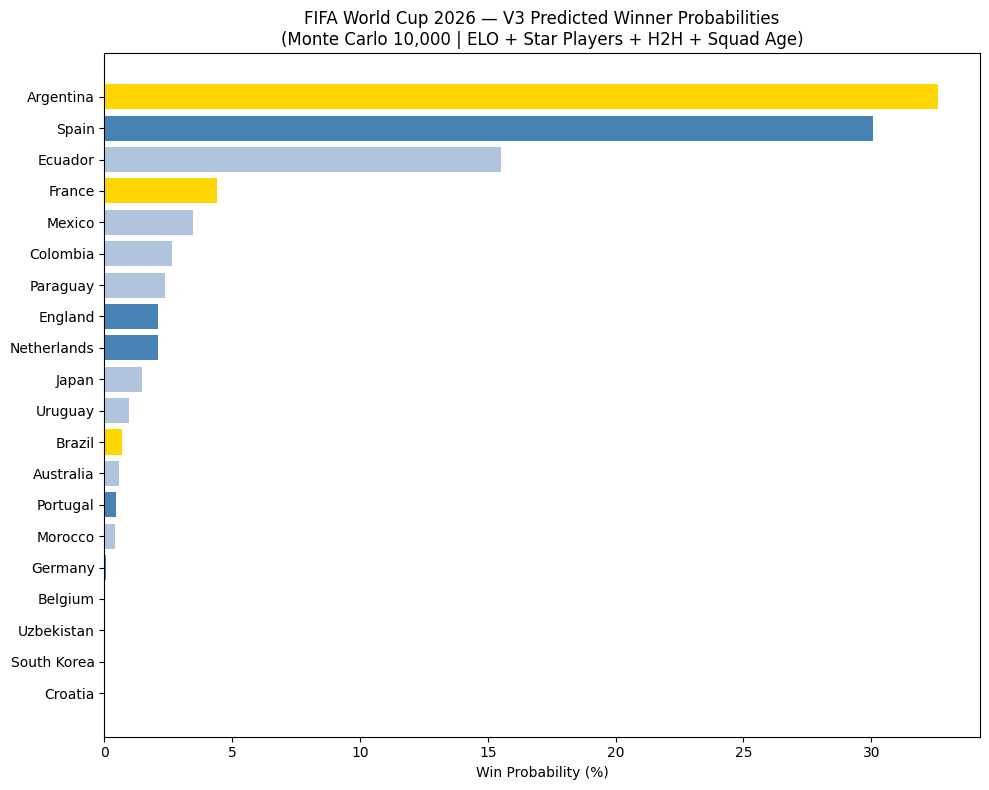

Saved!


In [9]:
top20 = results_df.head(20).sort_values('Win Probability (%)', ascending=True)

colors = []
for team in top20['Team']:
    if team in ['France', 'Argentina', 'Brazil']:
        colors.append('gold')
    elif team in ['England', 'Spain', 'Germany', 'Portugal', 'Netherlands']:
        colors.append('steelblue')
    else:
        colors.append('lightsteelblue')

plt.figure(figsize=(10, 8))
plt.barh(top20['Team'], top20['Win Probability (%)'], color=colors)
plt.xlabel('Win Probability (%)')
plt.title('FIFA World Cup 2026 — V3 Predicted Winner Probabilities\n(Monte Carlo 10,000 | ELO + Star Players + H2H + Squad Age)')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Monte_Carlo_Simulation', 'wc2026_predictions_v3.png'))
plt.show()

results_df.to_csv(os.path.join(BASE, 'Monte_Carlo_Simulation', 'predictions_v3.csv'), index=False)
print("Saved!")